# Data Exploration

This dataframe explores and visualizes the dataset collected.
Running this notebook requires recorded data, which can be generated by running this example in RECORD mode (see Readme.md).

In [6]:
# set working directoy to root directory of the project
if not "working_directory_corrected" in vars():
    %cd ..
    %cd ..
    %cd ..
    working_directory_corrected = True
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from  matplotlib.colors import LinearSegmentedColormap


from examples.room_change_scenario.src.room_change_scenario import create_room_change_scenario

## Data Loading

Below we load the dataset and observe it's general properties.
We also create a second dataset with day-averages to make visualization easier.

In [7]:
scenario = create_room_change_scenario()
complete_data = pd.read_pickle("examples/room_change_scenario/data/recording.pickle")
complete_data.set_index(pd.DatetimeIndex(complete_data["date"]), inplace=True)
complete_data.drop(labels = ["prediction_time","adaptation_time","prediction_0","prediction_1","prediction_2","prediction_3","prediction_4","prediction_5","prediction_6","prediction_7"], axis = 1, inplace= True)

day_averages = complete_data.resample("D").mean()

room_names = scenario.get_room_names()
nr_rooms = len(room_names)

print(f"The dataframe has {len(complete_data)} samples.")
print(f"The example scenario has {nr_rooms} rooms.")
print("below are five random samples")
day_averages

The dataframe has 432000 samples.
The example scenario has 8 rooms.
below are five random samples


,date,weather,room_0,room_1,room_2,room_3,room_4,room_5,room_6,room_7
date,,,,,,,,,,
2020-01-01,2020-01-01 11:59:30,0.020545,0.0,0.500694,0.009028,0.008333,0.133333,0.499306,0.079167,0.061806
2020-01-02,2020-01-02 11:59:30,0.000000,0.0,0.456944,0.005556,0.004861,0.147222,0.481250,0.138889,0.048611
2020-01-03,2020-01-03 11:59:30,0.025647,0.0,0.458333,0.005556,0.005556,0.202778,0.423611,0.121528,0.062500
2020-01-04,2020-01-04 11:59:30,0.000000,0.0,0.498611,0.012500,0.013194,0.385417,0.269444,0.148611,0.184028
2020-01-05,2020-01-05 11:59:30,0.054099,0.0,0.550694,0.010417,0.012500,0.438889,0.259722,0.119444,0.091667
...,...,...,...,...,...,...,...,...,...,...
2020-10-22,2020-10-22 11:59:30,0.207427,0.0,0.456944,0.006944,0.006250,0.110417,0.436806,0.136806,0.138194
2020-10-23,2020-10-23 11:59:30,0.254333,0.0,0.475000,0.007639,0.006944,0.117361,0.378472,0.138889,0.097222
2020-10-24,2020-10-24 11:59:30,0.265903,0.0,0.500694,0.013889,0.013194,0.302083,0.220833,0.236111,0.131944


## Room Occupation Heatmap

Here we visualize the occupancy of rooms based on a heatmap.

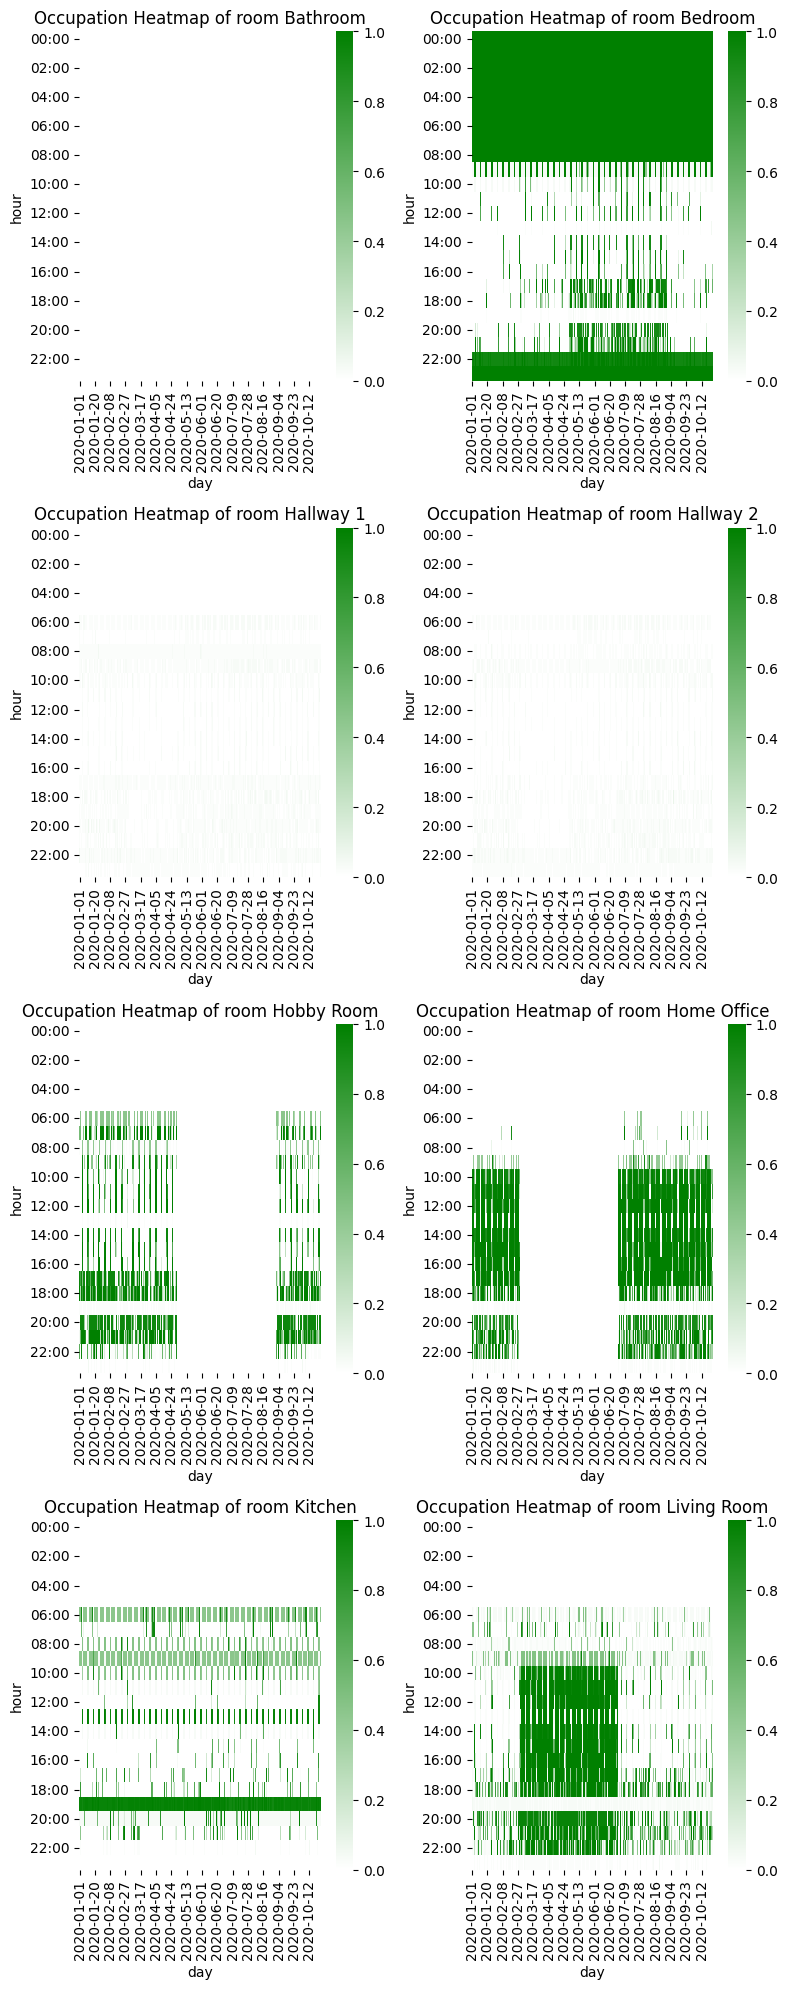

In [8]:


nr_cols = 2
fig, subplots = plt.subplots(ncols= nr_cols,nrows= (nr_rooms+1) //nr_cols, figsize = (8,20))

for room_index in range(nr_rooms):
   ax = subplots[room_index//nr_cols][room_index% nr_cols]
   ax.set_title(f"Occupation Heatmap of room {room_names[room_index]}")
   sns.heatmap(data =complete_data.groupby([complete_data.date.dt.strftime('%Y-%m-%d'), complete_data.date.dt.strftime('%H:00')])
      [f"room_{room_index}"].mean()
      .rename_axis(index=['day','hour'])
      .unstack(level=0),
      vmin= 0, 
      vmax = 1,
      cmap=LinearSegmentedColormap.from_list('rg',["w", "g"], N=256),
      ax=ax
   )

fig.tight_layout()
plt.show()

The heatmaps illustrate the effects of closing and opening rooms in several ways:
- The closure of office and hobby room lead to no presence being detected during these periods.
- During these times, we can see changes in the patterns of the Living Room and Bedroom, as these rooms are used instead of the closed rooms for certain activities. 


## Average Room Occupation
Below we visualize the day-averages of occupation for all rooms in the timeframe.

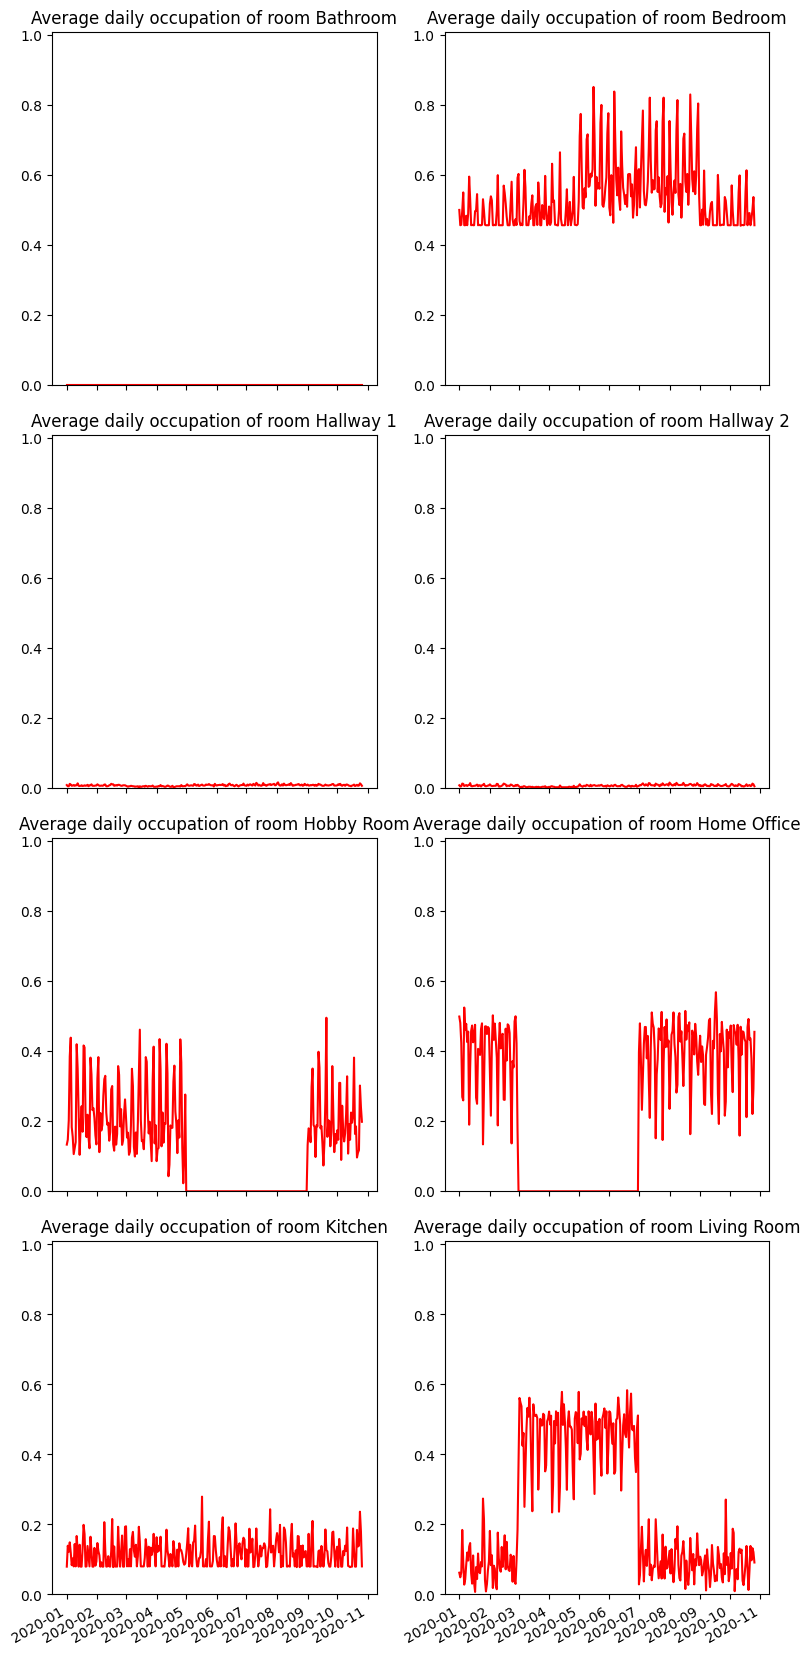

In [9]:

nr_cols = 2
fig, subplots = plt.subplots(ncols= nr_cols,nrows= (nr_rooms+1) //nr_cols, figsize = (8,20))

for room_index in range(nr_rooms):
    ax = subplots[room_index//nr_cols][room_index% nr_cols]
    ax.set_title(f"Average daily occupation of room {room_names[room_index]}")
    ax.plot(day_averages[f"room_{room_index}"],"r-")
    ax.set_ylim([0, 1.01])
    
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

The changes in occupation can also be observed in the daily averages, with Home Office and Hobby Room showing gaps during their closure periods and bedroom and living room having increased usage during these times. 